India Data Analyst Job Market Analysis

In [25]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use('seaborn-v0_8-darkgrid')

df= pd.read_csv('../data/all_market_data_with_skills.csv')
df['source'] = df['source'].fillna('Naukri')
print(df['source'].value_counts())
print(f"Total jobs loaded: {len(df)}")
print(f"Sources: {df['source'].value_counts()}")
df.head(3)

source
Naukri     324
Foundit    287
Name: count, dtype: int64
Total jobs loaded: 611
Sources: source
Naukri     324
Foundit    287
Name: count, dtype: int64


,job_id,Title,Company,Experience,Location,Description,Posted_Date,Skills_Listed,Job_URL,date_scraped,...,GenAI,Deep Learning,NLP,Data Visualization,Hadoop,Airflow,Docker,BigQuery,SAS,total_skills_found
0,21225014173,Data Analyst,Capgemini,4-9 Yrs,"Hybrid - Chennai, Delhi / NCR, Mumbai (All Areas)",Required Skills & Qualifications: . Bachelors ...,3+ weeks ago,"Power Bi, Data Analysis, Data Visualization, T...",https://www.naukri.com/job-listings-data-analy...,2026-06-22,...,0,0,0,1,0,0,0,0,0,5
1,221025507695,Data Analyst,Snapdeal,1-6 Yrs,Gurugram,Providing technical expertise in data storage ...,3+ weeks ago,"master data, python, metadata, data analysis, ...",https://www.naukri.com/job-listings-data-analy...,2026-06-22,...,0,0,0,0,0,0,0,0,0,1
2,200326006395,Data Analyst,Kiya.ai,3-7 Yrs,"Hybrid - Bengaluru, Mumbai (All Areas)",Must possess the ability to research and resol...,4 days ago,"Power Bi, Data Analysis, Tableau, SQL, Capital...",https://www.naukri.com/job-listings-data-analy...,2026-06-22,...,0,0,0,0,0,0,0,0,0,3


In [26]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 611 entries, 0 to 610
Data columns (total 42 columns):
 #   Column              Non-Null Count  Dtype
---  ------              --------------  -----
 0   job_id              611 non-null    str  
 1   Title               611 non-null    str  
 2   Company             610 non-null    str  
 3   Experience          603 non-null    str  
 4   Location            611 non-null    str  
 5   Description         605 non-null    str  
 6   Posted_Date         611 non-null    str  
 7   Skills_Listed       604 non-null    str  
 8   Job_URL             611 non-null    str  
 9   date_scraped        611 non-null    str  
 10  source              611 non-null    str  
 11  SQL                 611 non-null    int64
 12  Python              611 non-null    int64
 13  Excel               611 non-null    int64
 14  Power BI            611 non-null    int64
 15  Tableau             611 non-null    int64
 16  AWS                 611 non-null    int64
 17  Azure   

Data Cleaning 

In [27]:
print(df[['Title', 'Company', 'Location', 'Experience']].isna().sum())
# Drop rows where Title or Company is missing — these are unusable
df = df.dropna(subset=['Title', 'Company'])
print(f"Jobs after dropping missing Title/Company: {len(df)}")

Title         0
Company       1
Location      0
Experience    8
dtype: int64
Jobs after dropping missing Title/Company: 610


In [28]:
# Cleaning experience column to extract min experience in years


import re

def extract_min_experience(exp_text):
    if pd.isna(exp_text) or exp_text == 'N/A':
        return np.nan
    match = re.search(r'(\d+)', str(exp_text))
    if match:
        return int(match.group(1))
    return np.nan

df['min_experience'] = df['Experience'].apply(extract_min_experience)
df[['Experience', 'min_experience']].head(10)


# Create experience level buckets
def experience_bucket(years):
    if pd.isna(years):
        return 'Unknown'
    elif years == 0:
        return 'Fresher (0 yrs)'
    elif years <= 2:
        return 'Junior (0-2 yrs)'
    elif years <= 5:
        return 'Mid (3-5 yrs)'
    else:
        return 'Senior (5+ yrs)'

df['experience_level'] = df['min_experience'].apply(experience_bucket)
df['experience_level'].value_counts()



experience_level
Mid (3-5 yrs)       258
Junior (0-2 yrs)    139
Senior (5+ yrs)     106
Fresher (0 yrs)      68
Unknown              39
Name: count, dtype: int64

In [29]:
# Clean Posted_Date into recency buckets
def clean_posted_date(date_text):
    date_text = str(date_text).lower()
    if 'today' in date_text or 'few hours' in date_text:
        return 'Today'
    elif 'day' in date_text:
        return 'This Week'
    elif '1 week' in date_text:
        return '1-2 Weeks'
    elif '2 week' in date_text:
        return '2-3 Weeks'
    elif '3+' in date_text or '3 week' in date_text:
        return '3+ Weeks'
    else:
        return 'Unknown'

df['recency_bucket'] = df['Posted_Date'].apply(clean_posted_date)
df['recency_bucket'].value_counts()

recency_bucket
This Week    198
3+ Weeks     160
Unknown      153
1-2 Weeks     50
2-3 Weeks     29
Today         20
Name: count, dtype: int64

In [30]:
# Clean Location — split multi-location postings, take primary location
def clean_location(loc_text):
    if pd.isna(loc_text):
        return 'Unknown'
    loc_text = str(loc_text).replace('Hybrid - ', '').strip()
    primary = loc_text.split(',')[0].strip()
    return primary

df['primary_location'] = df['Location'].apply(clean_location)
df['primary_location'].value_counts().head(15)

primary_location
Bengaluru             161
Hyderabad              61
Pune                   59
Gurugram               52
India                  49
Mumbai                 38
Chennai                37
Noida                  26
Remote                 15
New Delhi              15
Mumbai (All Areas)      9
Kolkata                 8
Ahmedabad               6
Navi Mumbai             4
Nagpur                  3
Name: count, dtype: int64

In [31]:
# Consolidate location variants
location_map = {
    'Mumbai (All Areas)': 'Mumbai',
    'Navi Mumbai': 'Mumbai',
    'Pimpri-Chinchwad': 'Pune',
    'Noida': 'Delhi NCR',
    'New Delhi': 'Delhi NCR',
    'Gurugram': 'Delhi NCR',
    'Delhi': 'Delhi NCR',
    'Bengaluru': 'Bengaluru',
    'Hyderabad/Secunderabad': 'Hyderabad',
    'Cochin / Kochi / Ernakulam': 'Kochi'
}

df['primary_location'] = df['primary_location'].replace(location_map)
df['primary_location'].value_counts().head(10)

primary_location
Bengaluru    161
Delhi NCR     94
Hyderabad     61
Pune          60
Mumbai        51
India         49
Chennai       37
Remote        15
Kolkata        8
Ahmedabad      6
Name: count, dtype: int64

Skill Frequency Analysis

In [32]:
skill_columns = [
    'SQL', 'Python', 'Excel', 'Power BI', 'Tableau', 'AWS', 'Azure', 'GCP',
    'Machine Learning', 'Statistics', 'R', 'Spark', 'Git', 'Pandas', 'NumPy',
    'Scikit-learn', 'Looker', 'DAX', 'Snowflake', 'ETL', 'Power Query',
    'GenAI', 'Deep Learning', 'NLP', 'Data Visualization', 'Hadoop',
    'Airflow', 'Docker', 'BigQuery', 'SAS'
]
skill_demand = df[skill_columns].sum().sort_values(ascending=False)
skill_demand_pct = (skill_demand / len(df) * 100).round(1)
skill_summary = pd.DataFrame({
    'job_count': skill_demand,
    'demand_pct': skill_demand_pct
})
print(skill_summary.to_string())


                    job_count  demand_pct
SQL                       316        51.8
Python                    239        39.2
Power BI                  239        39.2
Excel                     142        23.3
Tableau                   124        20.3
Data Visualization         76        12.5
Statistics                 56         9.2
ETL                        43         7.0
Machine Learning           39         6.4
Snowflake                  32         5.2
Azure                      30         4.9
AWS                        28         4.6
Looker                     27         4.4
Spark                      25         4.1
Power Query                21         3.4
DAX                        21         3.4
SAS                        21         3.4
GCP                        21         3.4
BigQuery                   18         3.0
Pandas                     15         2.5
Git                        11         1.8
GenAI                      10         1.6
NumPy                       8     

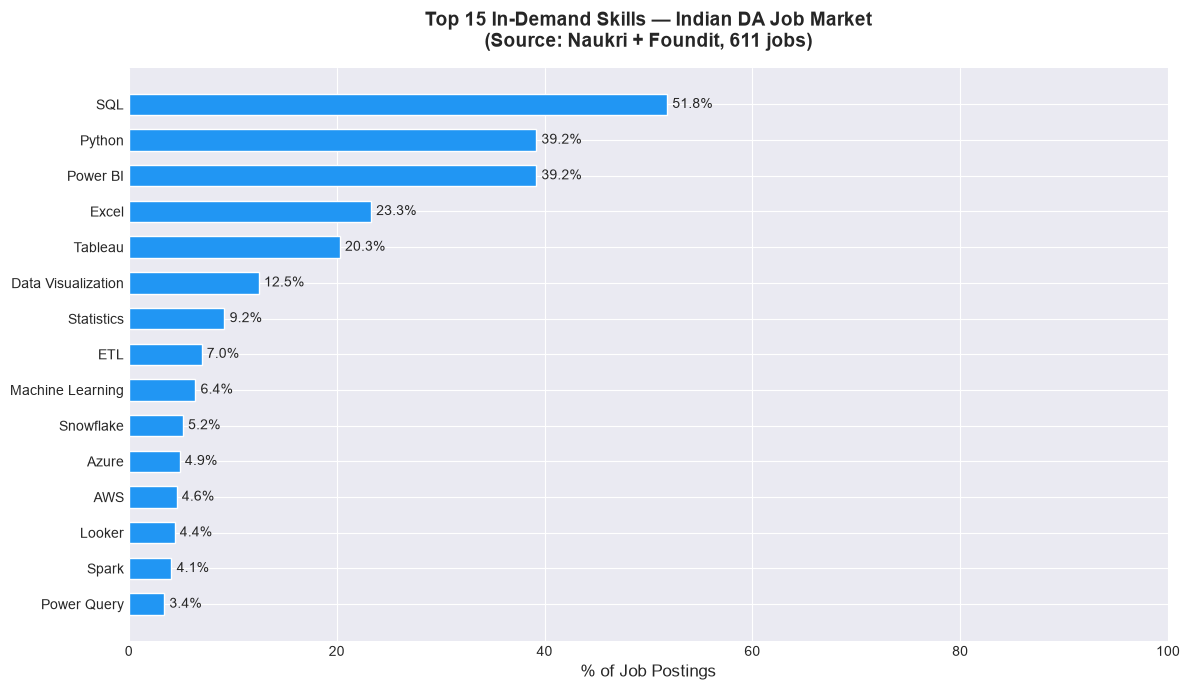

Chart saved.


In [33]:
# Chart 1 — Top 15 Skills by Demand
fig, ax = plt.subplots(figsize=(12, 7))

top_15 = skill_summary.head(15)

bars = ax.barh(
    top_15.index[::-1],
    top_15['demand_pct'][::-1],
    color='#2196F3',
    edgecolor='white',
    height=0.6
)

# Add percentage labels on bars
for bar, pct in zip(bars, top_15['demand_pct'][::-1]):
    ax.text(
        bar.get_width() + 0.5,
        bar.get_y() + bar.get_height()/2,
        f'{pct}%',
        va='center',
        fontsize=10
    )

ax.set_xlabel('% of Job Postings', fontsize=12)
ax.set_title('Top 15 In-Demand Skills — Indian DA Job Market\n(Source: Naukri + Foundit, 611 jobs)', 
             fontsize=14, fontweight='bold', pad=15)
ax.set_xlim(0, 100)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.savefig('../data/top_skills_demand.png', dpi=150, bbox_inches='tight')
plt.show()
print("Chart saved.")

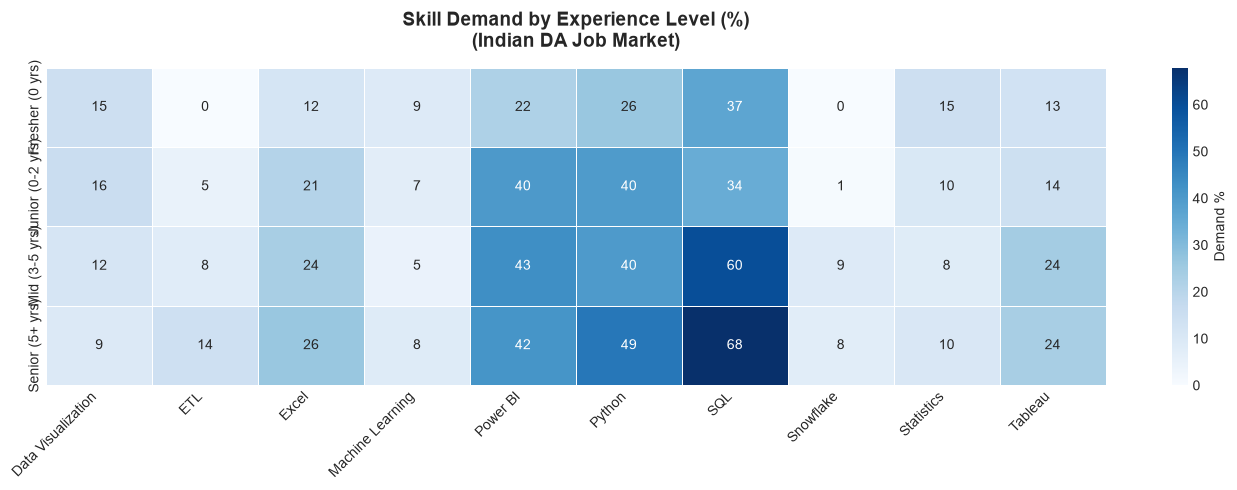

Chart saved.


In [34]:
# Chart 2 — Skill Demand by Experience Level

exp_levels = ['Fresher (0 yrs)', 'Junior (0-2 yrs)', 'Mid (3-5 yrs)', 'Senior (5+ yrs)']
top_10_skills = skill_summary.head(10).index.tolist()


exp_skill_data = []
for level in exp_levels:
    level_df = df[df['experience_level'] == level]
    if len(level_df) == 0:
        continue
    for skill in top_10_skills:
        pct = level_df[skill].mean() * 100
        exp_skill_data.append({
            'experience_level': level,
            'skill': skill,
            'demand_pct': round(pct, 1)
        })

exp_skill_df = pd.DataFrame(exp_skill_data)

# Pivot for heatmap
pivot = exp_skill_df.pivot(
    index='experience_level', 
    columns='skill', 
    values='demand_pct'
)
pivot = pivot.reindex(exp_levels)

fig, ax = plt.subplots(figsize=(14, 5))
sns.heatmap(
    pivot,
    annot=True,
    fmt='.0f',
    cmap='Blues',
    linewidths=0.5,
    ax=ax,
    cbar_kws={'label': 'Demand %'}
)
ax.set_title('Skill Demand by Experience Level (%)\n(Indian DA Job Market)', 
             fontsize=14, fontweight='bold', pad=15)
ax.set_xlabel('')
ax.set_ylabel('')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig('../data/skill_by_experience.png', dpi=150, bbox_inches='tight')
plt.show()
print("Chart saved.")

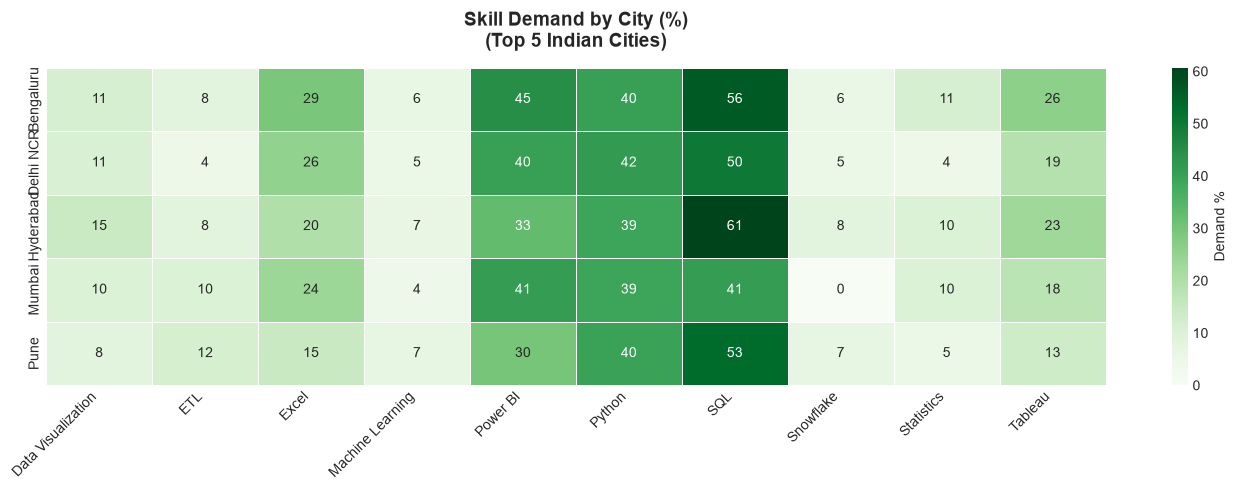

Chart saved.


In [35]:
# Chart 3 — Skill Demand by Top 5 Cities
top_cities = df['primary_location'].value_counts().head(5).index.tolist()
top_10_skills = skill_summary.head(10).index.tolist()

city_skill_data = []
for city in top_cities:
    city_df = df[df['primary_location'] == city]
    for skill in top_10_skills:
        pct = city_df[skill].mean() * 100
        city_skill_data.append({
            'city': city,
            'skill': skill,
            'demand_pct': round(pct, 1)
        })

city_skill_df = pd.DataFrame(city_skill_data)

pivot_city = city_skill_df.pivot(
    index='city',
    columns='skill',
    values='demand_pct'
)

fig, ax = plt.subplots(figsize=(14, 5))
sns.heatmap(
    pivot_city,
    annot=True,
    fmt='.0f',
    cmap='Greens',
    linewidths=0.5,
    ax=ax,
    cbar_kws={'label': 'Demand %'}
)
ax.set_title('Skill Demand by City (%)\n(Top 5 Indian Cities)', 
             fontsize=14, fontweight='bold', pad=15)
ax.set_xlabel('')
ax.set_ylabel('')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig('../data/skill_by_city.png', dpi=150, bbox_inches='tight')
plt.show()
print("Chart saved.")

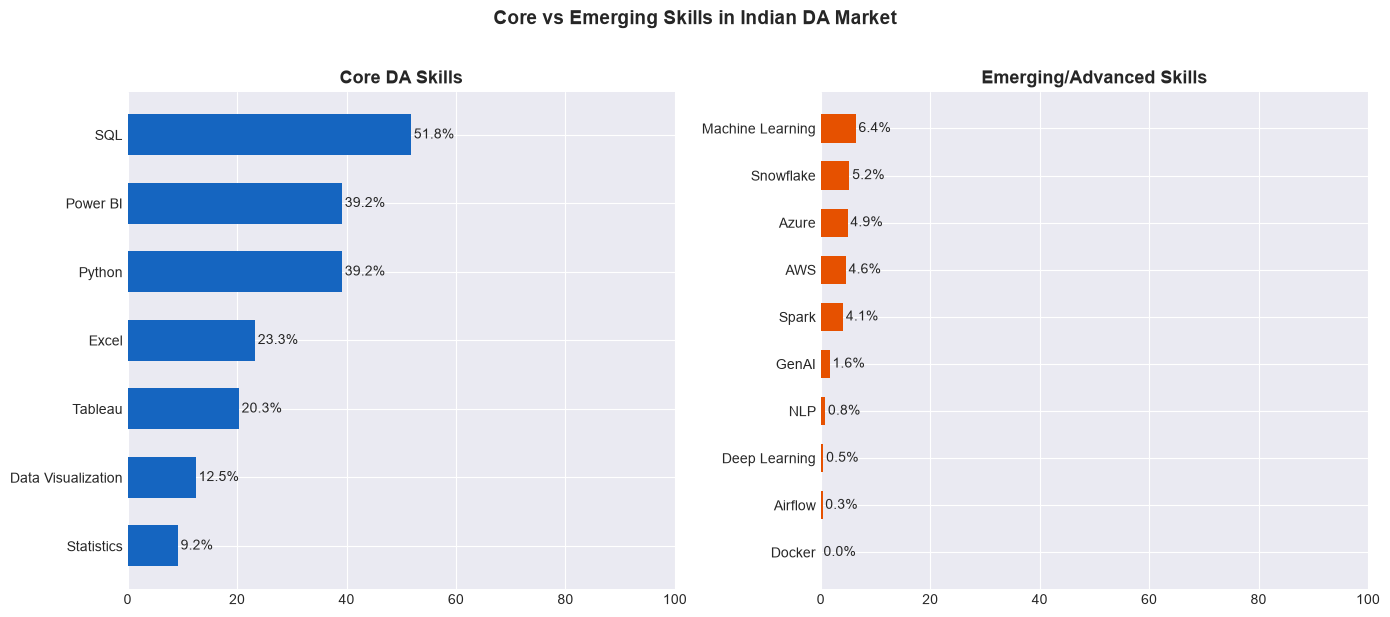

Chart saved.


In [36]:
# Chart 4 — Skills split: Core vs Emerging
core_skills = ['SQL', 'Python', 'Excel', 'Power BI', 'Tableau', 
               'Statistics', 'Data Visualization']
emerging_skills = ['Machine Learning', 'GenAI', 'Deep Learning', 'NLP', 
                   'Spark', 'Airflow', 'Snowflake', 'Docker', 'AWS', 'Azure']

core_avg = df[core_skills].mean().mean() * 100
emerging_avg = df[emerging_skills].mean().mean() * 100

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Core skills
core_vals = (df[core_skills].mean() * 100).sort_values(ascending=True)
axes[0].barh(core_vals.index, core_vals.values, color='#1565C0', height=0.6)
for i, v in enumerate(core_vals.values):
    axes[0].text(v + 0.5, i, f'{v:.1f}%', va='center', fontsize=10)
axes[0].set_title('Core DA Skills', fontsize=13, fontweight='bold')
axes[0].set_xlim(0, 100)
axes[0].spines['top'].set_visible(False)
axes[0].spines['right'].set_visible(False)

# Emerging skills
emerging_vals = (df[emerging_skills].mean() * 100).sort_values(ascending=True)
axes[1].barh(emerging_vals.index, emerging_vals.values, color='#E65100', height=0.6)
for i, v in enumerate(emerging_vals.values):
    axes[1].text(v + 0.5, i, f'{v:.1f}%', va='center', fontsize=10)
axes[1].set_title('Emerging/Advanced Skills', fontsize=13, fontweight='bold')
axes[1].set_xlim(0, 100)
axes[1].spines['top'].set_visible(False)
axes[1].spines['right'].set_visible(False)

plt.suptitle('Core vs Emerging Skills in Indian DA Market', 
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('../data/core_vs_emerging.png', dpi=150, bbox_inches='tight')
plt.show()
print("Chart saved.")

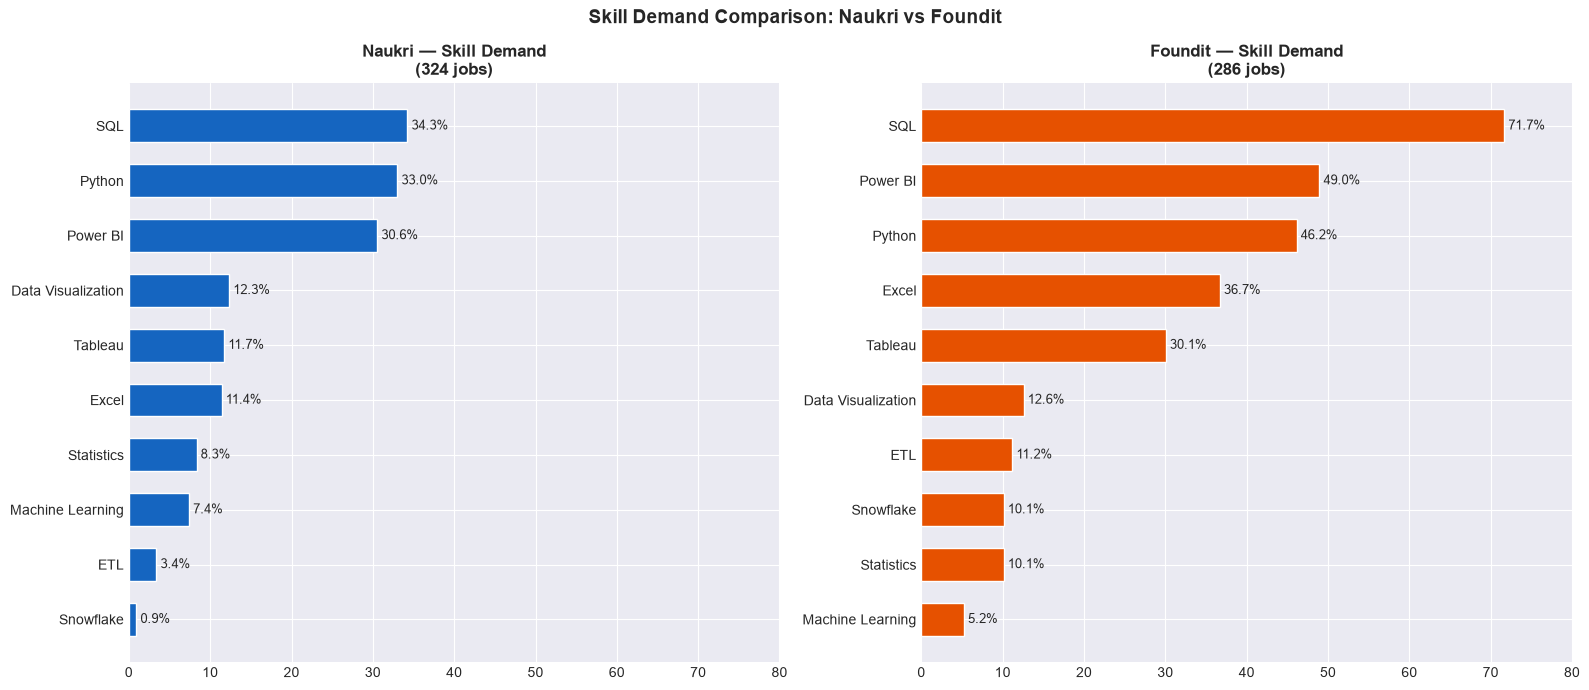

Chart saved.


In [37]:
# Source comparison — Naukri vs Foundit skill demand
fig, axes = plt.subplots(1, 2, figsize=(16, 7))

top_10_skills = skill_summary.head(10).index.tolist()
sources = ['Naukri', 'Foundit']
colors = ['#1565C0', '#E65100']

for idx, source in enumerate(sources):
    source_df = df[df['source'] == source]
    source_demand = (source_df[top_10_skills].mean() * 100).sort_values(ascending=True)
    
    axes[idx].barh(
        source_demand.index,
        source_demand.values,
        color=colors[idx],
        height=0.6,
        edgecolor='white'
    )
    for i, v in enumerate(source_demand.values):
        axes[idx].text(v + 0.5, i, f'{v:.1f}%', va='center', fontsize=9)
    
    axes[idx].set_title(
        f'{source} — Skill Demand\n({len(source_df)} jobs)',
        fontsize=12, fontweight='bold'
    )
    axes[idx].set_xlim(0, 80)
    axes[idx].spines['top'].set_visible(False)
    axes[idx].spines['right'].set_visible(False)

plt.suptitle(
    'Skill Demand Comparison: Naukri vs Foundit',
    fontsize=14, fontweight='bold'
)
plt.tight_layout()
plt.savefig('../data/source_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print("Chart saved.")

Co-occurance Analysis

In [38]:
# Cell 1 — Building the co-occurrence matrix
# For each pair of skills, count how many jobs mention both

# Using only top 15 skills for cleaner visualization
top_15_skills = skill_summary.head(15).index.tolist()
skill_matrix = df[top_15_skills]


# When two columns both have 1 in same row, product = 1
co_occurrence = skill_matrix.T.dot(skill_matrix)

# Converting counts to percentages (out of total jobs)
co_occurrence_pct = (co_occurrence / len(df) * 100).round(1)

# Setting diagonal to 0 — a skill co-occurring with itself isn't useful
for i in range(len(co_occurrence_pct)):
    co_occurrence_pct.iat[i, i] = 0

print("Co-occurrence matrix (% of jobs where both skills appear together):")
print(co_occurrence_pct.to_string())

Co-occurrence matrix (% of jobs where both skills appear together):
                     SQL  Python  Power BI  Excel  Tableau  Data Visualization  Statistics  ETL  Machine Learning  Snowflake  Azure  AWS  Looker  Spark  Power Query
SQL                  0.0    26.7      26.4   14.6     16.4                 8.4         5.9  5.6               3.4        4.9    4.4  3.9     4.3    3.4          2.6
Python              26.7     0.0      20.0    9.2     13.3                 5.1         5.1  3.6               3.4        3.1    3.3  3.3     3.0    3.3          1.1
Power BI            26.4    20.0       0.0   14.4     16.1                 7.4         3.9  3.3               1.5        2.6    3.8  2.3     3.1    1.3          3.3
Excel               14.6     9.2      14.4    0.0      7.4                 3.6         1.3  0.3               0.3        1.0    0.7  0.5     0.8    0.5          1.6
Tableau             16.4    13.3      16.1    7.4      0.0                 3.6         3.0  1.6            

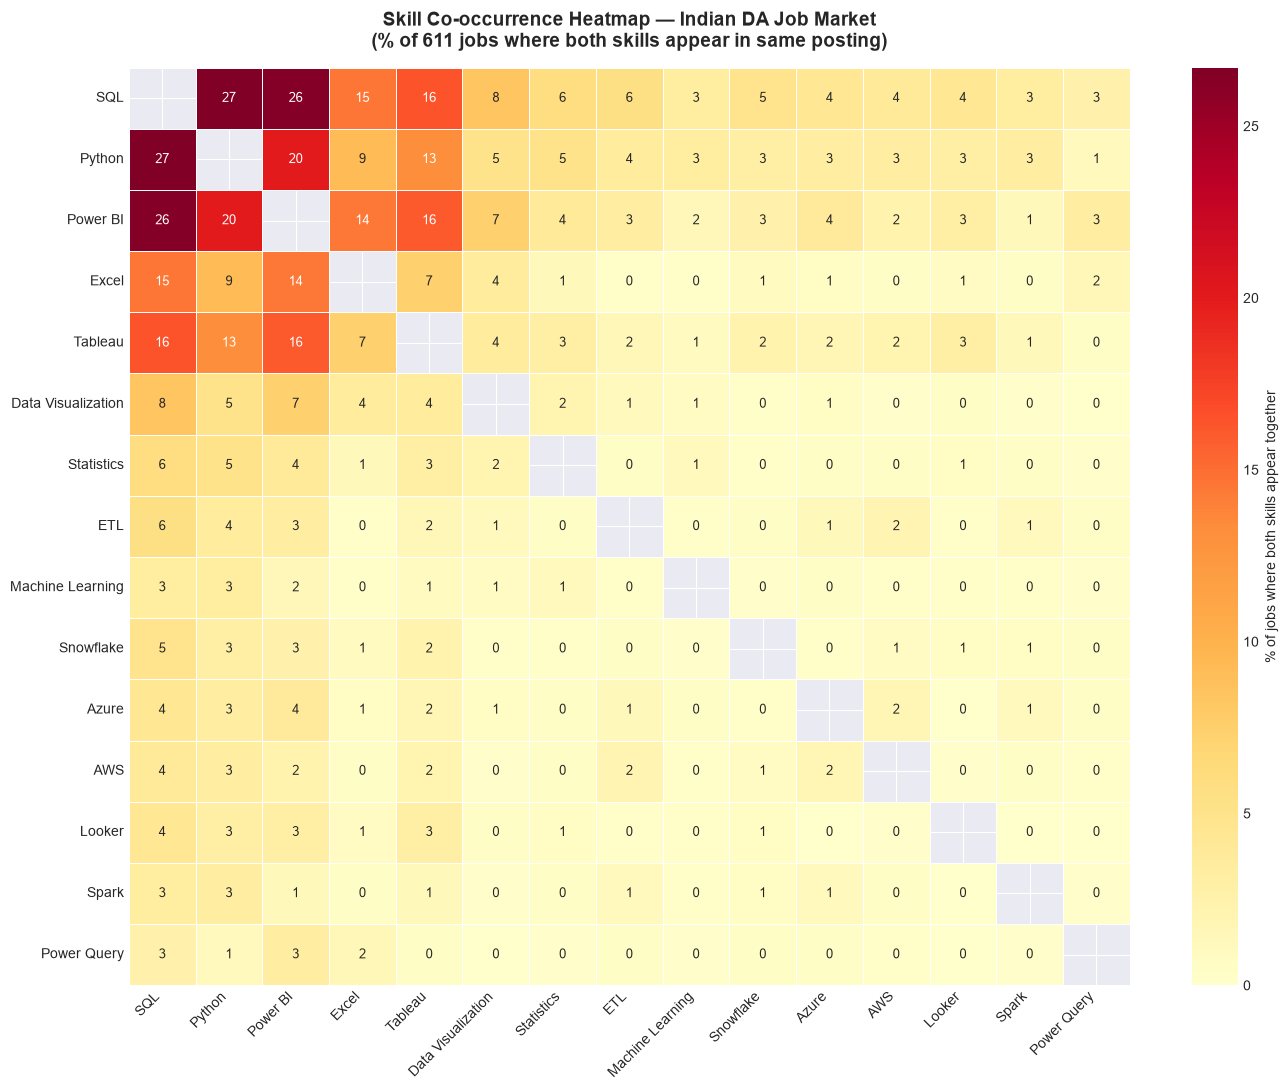

Chart saved.


In [39]:
# Cell 2 — Co-occurrence Heatmap
fig, ax = plt.subplots(figsize=(14, 11))

mask = np.zeros_like(co_occurrence_pct, dtype=bool)
np.fill_diagonal(mask, True)

sns.heatmap(
    co_occurrence_pct,
    annot=True,
    fmt='.0f',
    cmap='YlOrRd',
    linewidths=0.5,
    ax=ax,
    mask=mask,
    cbar_kws={'label': '% of jobs where both skills appear together'},
    annot_kws={'size': 9}
)

ax.set_title(
    'Skill Co-occurrence Heatmap — Indian DA Job Market\n'
    '(% of 611 jobs where both skills appear in same posting)',
    fontsize=14, fontweight='bold', pad=15
)
plt.xticks(rotation=45, ha='right', fontsize=10)
plt.yticks(rotation=0, fontsize=10)
plt.tight_layout()
plt.savefig('../data/skill_cooccurrence_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()
print("Chart saved.")

In [40]:
# Cell 3 — Top 15 strongest skill pairs
# Find the most commonly co-occurring pairs

pairs = []
skills = top_15_skills

for i in range(len(skills)):
    for j in range(i+1, len(skills)):  
        skill_a = skills[i]
        skill_b = skills[j]
        count = co_occurrence_pct.loc[skill_a, skill_b]
        pairs.append({
            'Skill A': skill_a,
            'Skill B': skill_b,
            'Co-occurrence %': count,
            'Jobs Together': int(co_occurrence.loc[skill_a, skill_b])
        })

pairs_df = pd.DataFrame(pairs)
pairs_df = pairs_df.sort_values('Co-occurrence %', ascending=False)

print("Top 20 most common skill combinations:")
print(pairs_df.head(20).to_string(index=False))

Top 20 most common skill combinations:
 Skill A            Skill B  Co-occurrence %  Jobs Together
     SQL             Python             26.7            163
     SQL           Power BI             26.4            161
  Python           Power BI             20.0            122
     SQL            Tableau             16.4            100
Power BI            Tableau             16.1             98
     SQL              Excel             14.6             89
Power BI              Excel             14.4             88
  Python            Tableau             13.3             81
  Python              Excel              9.2             56
     SQL Data Visualization              8.4             51
Power BI Data Visualization              7.4             45
   Excel            Tableau              7.4             45
     SQL         Statistics              5.9             36
     SQL                ETL              5.6             34
  Python Data Visualization              5.1             31
 

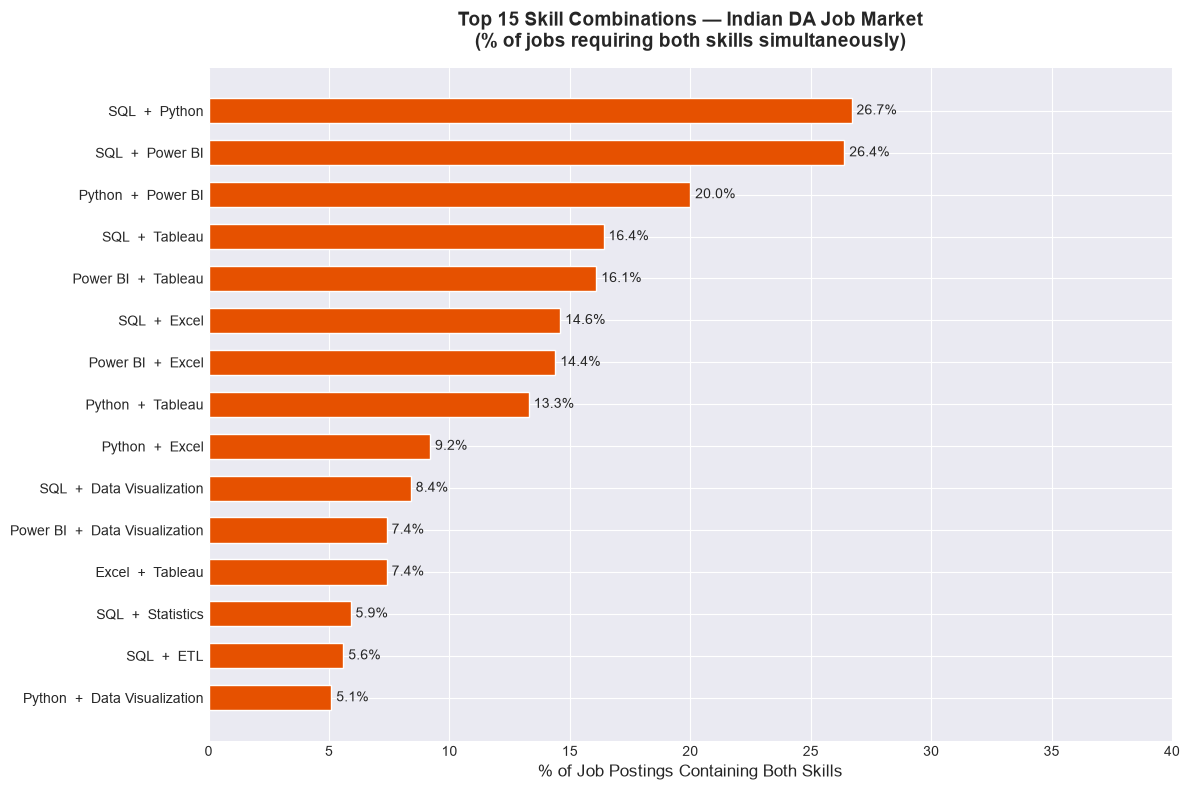

Chart saved.


In [41]:
# Cell 4 — Visualise top skill pairs
fig, ax = plt.subplots(figsize=(12, 8))

top_pairs = pairs_df.head(15).copy()
top_pairs['pair_label'] = top_pairs['Skill A'] + '  +  ' + top_pairs['Skill B']

bars = ax.barh(
    top_pairs['pair_label'][::-1],
    top_pairs['Co-occurrence %'][::-1],
    color='#E65100',
    height=0.6,
    edgecolor='white'
)

for bar, pct in zip(bars, top_pairs['Co-occurrence %'][::-1]):
    ax.text(
        bar.get_width() + 0.2,
        bar.get_y() + bar.get_height()/2,
        f'{pct:.1f}%',
        va='center',
        fontsize=10
    )

ax.set_xlabel('% of Job Postings Containing Both Skills', fontsize=12)
ax.set_title(
    'Top 15 Skill Combinations — Indian DA Job Market\n'
    '(% of jobs requiring both skills simultaneously)',
    fontsize=14, fontweight='bold', pad=15
)
ax.set_xlim(0, 40)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.savefig('../data/top_skill_pairs.png', dpi=150, bbox_inches='tight')
plt.show()
print("Chart saved.")

In [42]:
# Cell 5 — Skill cluster profiles
# What skill profile does a typical DA job ask for?
# Group jobs by their dominant skill combination

def get_skill_profile(row):
    has_sql = row['SQL']
    has_python = row['Python']
    has_powerbi = row['Power BI']
    has_tableau = row['Tableau']
    has_ml = row['Machine Learning']

    if has_python and has_ml:
        return 'ML/Analytics Engineer'
    elif has_python and has_sql and has_powerbi:
        return 'Full Stack DA (Python+SQL+PowerBI)'
    elif has_sql and has_powerbi and not has_python:
        return 'BI Analyst (SQL+PowerBI)'
    elif has_sql and has_tableau and not has_python:
        return 'BI Analyst (SQL+Tableau)'
    elif has_python and has_sql and not has_powerbi:
        return 'Data/Analytics Engineer'
    elif has_sql and not has_python and not has_powerbi:
        return 'SQL Analyst'
    elif has_python and not has_sql:
        return 'Python Analyst'
    else:
        return 'General Analyst'

df['skill_profile'] = df.apply(get_skill_profile, axis=1)

profile_counts = df['skill_profile'].value_counts()
print("Skill profile distribution:")
print(profile_counts)

Skill profile distribution:
skill_profile
General Analyst                       218
Full Stack DA (Python+SQL+PowerBI)     88
SQL Analyst                            80
Python Analyst                         70
BI Analyst (SQL+PowerBI)               68
Data/Analytics Engineer                60
ML/Analytics Engineer                  21
BI Analyst (SQL+Tableau)                5
Name: count, dtype: int64


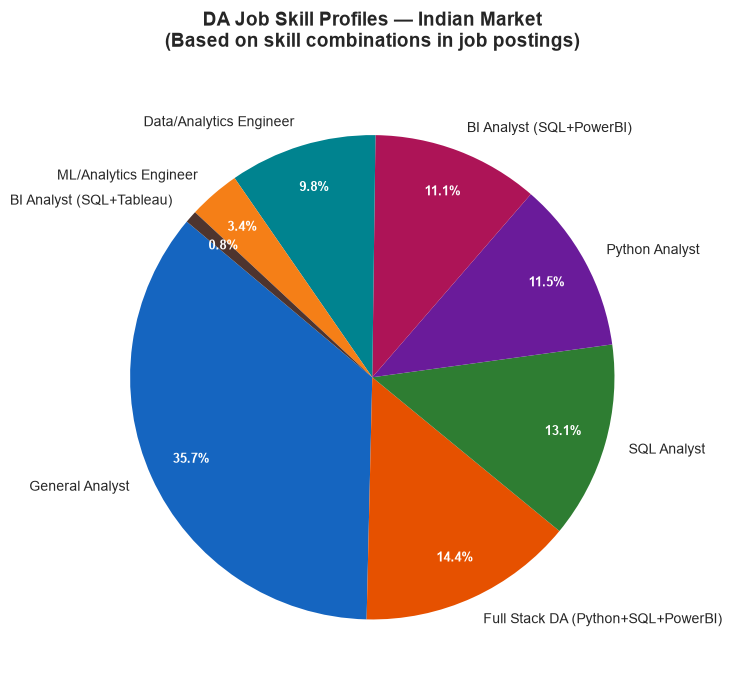

Chart saved.


In [43]:
# Cell 6 — Visualise skill profiles as pie chart
fig, ax = plt.subplots(figsize=(10, 7))

colors = ['#1565C0', '#E65100', '#2E7D32', '#6A1B9A', 
          '#AD1457', '#00838F', '#F57F17', '#4E342E']

wedges, texts, autotexts = ax.pie(
    profile_counts.values,
    labels=profile_counts.index,
    autopct='%1.1f%%',
    colors=colors[:len(profile_counts)],
    startangle=140,
    pctdistance=0.82
)

for text in texts:
    text.set_fontsize(10)
for autotext in autotexts:
    autotext.set_fontsize(9)
    autotext.set_color('white')
    autotext.set_fontweight('bold')

ax.set_title(
    'DA Job Skill Profiles — Indian Market\n'
    '(Based on skill combinations in job postings)',
    fontsize=14, fontweight='bold', pad=20
)
plt.tight_layout()
plt.savefig('../data/skill_profiles.png', dpi=150, bbox_inches='tight')
plt.show()
print("Chart saved.")

Experience Correlation Analysis

In [44]:
# Cell 1 — Skill demand vs experience required
# For each skill, what is the average minimum experience required?

skill_exp_data = []
for skill in skill_columns:
    skill_jobs = df[df[skill] == 1]['min_experience'].dropna()
    non_skill_jobs = df[df[skill] == 0]['min_experience'].dropna()
    
    if len(skill_jobs) > 5:  # only include if enough data points
        skill_exp_data.append({
            'skill': skill,
            'avg_exp_with_skill': round(skill_jobs.mean(), 1),
            'avg_exp_without_skill': round(non_skill_jobs.mean(), 1),
            'job_count': len(skill_jobs),
            'exp_premium': round(skill_jobs.mean() - non_skill_jobs.mean(), 1)
        })

exp_df = pd.DataFrame(skill_exp_data)
exp_df = exp_df.sort_values('avg_exp_with_skill', ascending=False)
print(exp_df.to_string(index=False))

             skill  avg_exp_with_skill  avg_exp_without_skill  job_count  exp_premium
             NumPy                 5.6                    3.6          7          2.0
            Hadoop                 5.4                    3.6          7          1.8
             Spark                 5.2                    3.6         24          1.6
         Snowflake                 5.1                    3.5         32          1.5
               ETL                 5.0                    3.5         42          1.4
             Azure                 4.9                    3.6         28          1.4
            Pandas                 4.9                    3.6         14          1.3
               GCP                 4.8                    3.6         20          1.2
       Power Query                 4.8                    3.6         20          1.2
               DAX                 4.7                    3.6         20          1.1
          BigQuery                 4.7                

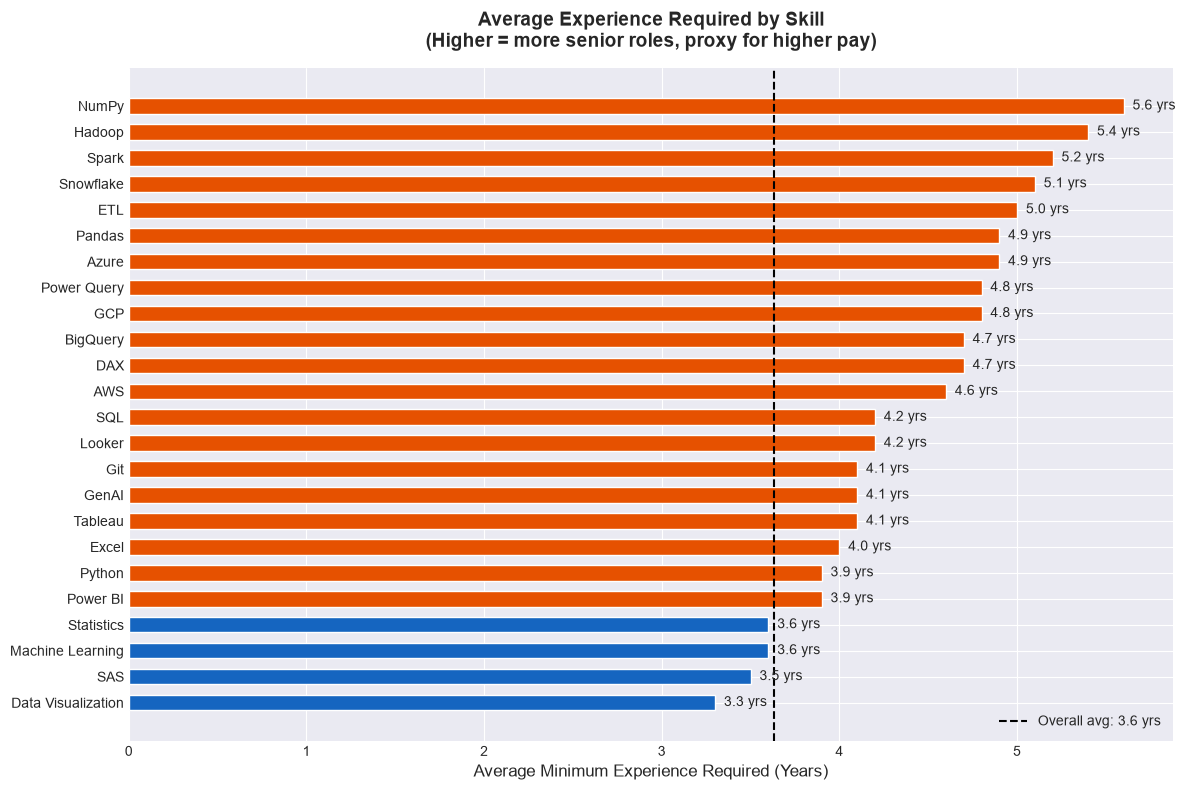

Chart saved.


In [45]:
# Cell 2 — Visualise average experience required per skill
fig, ax = plt.subplots(figsize=(12, 8))

exp_df_sorted = exp_df.sort_values('avg_exp_with_skill', ascending=True)

colors = ['#E65100' if x > 0 else '#1565C0' 
          for x in exp_df_sorted['exp_premium']]

bars = ax.barh(
    exp_df_sorted['skill'],
    exp_df_sorted['avg_exp_with_skill'],
    color=colors,
    height=0.6,
    edgecolor='white'
)

for bar, val in zip(bars, exp_df_sorted['avg_exp_with_skill']):
    ax.text(
        bar.get_width() + 0.05,
        bar.get_y() + bar.get_height()/2,
        f'{val} yrs',
        va='center',
        fontsize=10
    )

# Add overall average line
overall_avg = df['min_experience'].mean()
ax.axvline(x=overall_avg, color='black', linestyle='--', linewidth=1.5, 
           label=f'Overall avg: {overall_avg:.1f} yrs')

ax.set_xlabel('Average Minimum Experience Required (Years)', fontsize=12)
ax.set_title(
    'Average Experience Required by Skill\n'
    '(Higher = more senior roles, proxy for higher pay)',
    fontsize=14, fontweight='bold', pad=15
)
ax.legend(fontsize=10)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.savefig('../data/skill_experience_correlation.png', dpi=150, bbox_inches='tight')
plt.show()
print("Chart saved.")

In [46]:
# Cell 3 — Experience premium analysis
# Which skills appear in HIGHER experience roles than average?

print("="*55)
print("SKILL SENIORITY ANALYSIS")
print("="*55)
print(f"Overall average experience: {df['min_experience'].mean():.1f} years")
print("-"*55)

senior_skills = exp_df[exp_df['exp_premium'] > 0].sort_values(
    'exp_premium', ascending=False)
junior_skills = exp_df[exp_df['exp_premium'] <= 0].sort_values(
    'exp_premium', ascending=True)

print("\nSKILLS THAT APPEAR IN MORE SENIOR ROLES (higher pay proxy):")
for _, row in senior_skills.iterrows():
    print(f"  {row['skill']:<20} avg exp: {row['avg_exp_with_skill']} yrs  "
          f"(+{row['exp_premium']} yrs above average)")

print("\nSKILLS THAT APPEAR IN MORE JUNIOR/FRESHER ROLES:")
for _, row in junior_skills.iterrows():
    print(f"  {row['skill']:<20} avg exp: {row['avg_exp_with_skill']} yrs  "
          f"({row['exp_premium']} yrs vs average)")

SKILL SENIORITY ANALYSIS
Overall average experience: 3.6 years
-------------------------------------------------------

SKILLS THAT APPEAR IN MORE SENIOR ROLES (higher pay proxy):
  NumPy                avg exp: 5.6 yrs  (+2.0 yrs above average)
  Hadoop               avg exp: 5.4 yrs  (+1.8 yrs above average)
  Spark                avg exp: 5.2 yrs  (+1.6 yrs above average)
  Snowflake            avg exp: 5.1 yrs  (+1.5 yrs above average)
  ETL                  avg exp: 5.0 yrs  (+1.4 yrs above average)
  Azure                avg exp: 4.9 yrs  (+1.4 yrs above average)
  Pandas               avg exp: 4.9 yrs  (+1.3 yrs above average)
  GCP                  avg exp: 4.8 yrs  (+1.2 yrs above average)
  Power Query          avg exp: 4.8 yrs  (+1.2 yrs above average)
  SQL                  avg exp: 4.2 yrs  (+1.2 yrs above average)
  BigQuery             avg exp: 4.7 yrs  (+1.1 yrs above average)
  DAX                  avg exp: 4.7 yrs  (+1.1 yrs above average)
  AWS                  avg e

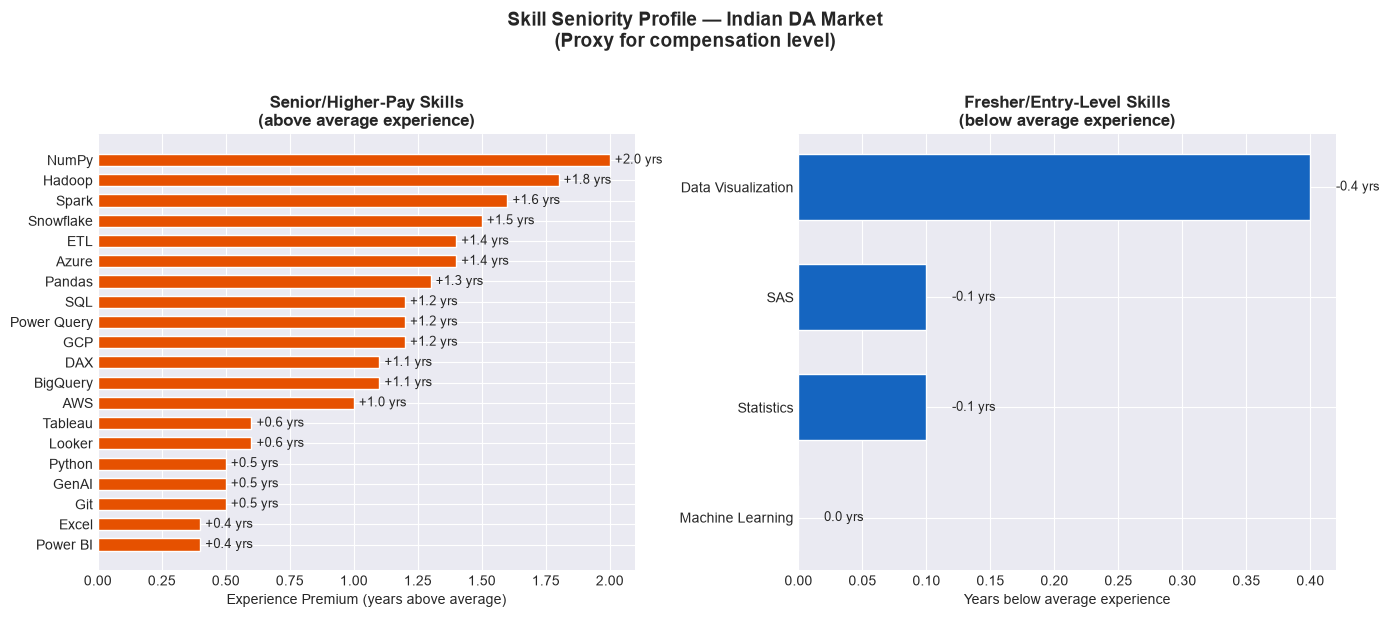

Chart saved.


In [47]:
# Cell 4 — Fresher-friendly vs Senior-heavy skill comparison
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

senior = exp_df[exp_df['exp_premium'] > 0].sort_values(
    'exp_premium', ascending=True)
junior = exp_df[exp_df['exp_premium'] <= 0].sort_values(
    'exp_premium', ascending=False)

# Senior skills
axes[0].barh(
    senior['skill'], 
    senior['exp_premium'],
    color='#E65100',
    height=0.6,
    edgecolor='white'
)
for i, (_, row) in enumerate(senior.iterrows()):
    axes[0].text(
        row['exp_premium'] + 0.02,
        i,
        f"+{row['exp_premium']} yrs",
        va='center', fontsize=9
    )
axes[0].set_title('Senior/Higher-Pay Skills\n(above average experience)', 
                   fontsize=12, fontweight='bold')
axes[0].set_xlabel('Experience Premium (years above average)')
axes[0].spines['top'].set_visible(False)
axes[0].spines['right'].set_visible(False)

# Junior skills
axes[1].barh(
    junior['skill'],
    junior['exp_premium'].abs(),
    color='#1565C0',
    height=0.6,
    edgecolor='white'
)
for i, (_, row) in enumerate(junior.iterrows()):
    axes[1].text(
        abs(row['exp_premium']) + 0.02,
        i,
        f"{row['exp_premium']} yrs",
        va='center', fontsize=9
    )
axes[1].set_title('Fresher/Entry-Level Skills\n(below average experience)',
                   fontsize=12, fontweight='bold')
axes[1].set_xlabel('Years below average experience')
axes[1].spines['top'].set_visible(False)
axes[1].spines['right'].set_visible(False)

plt.suptitle(
    'Skill Seniority Profile — Indian DA Market\n'
    '(Proxy for compensation level)',
    fontsize=14, fontweight='bold', y=1.02
)
plt.tight_layout()
plt.savefig('../data/skill_seniority_profile.png', dpi=150, bbox_inches='tight')
plt.show()
print("Chart saved.")

In [48]:
# Cell 5 — Note salary limitation clearly
print("""
DATA LIMITATION NOTE:
─────────────────────────────────────────────
Neither Naukri.com nor Foundit.in publicly display salary  
information in job listings for 99%+ of postings.

Direct salary correlation analysis was not possible.

Proxy used: Average minimum experience required 
per skill — higher experience requirements 
correlate with more senior, higher-paying roles.

For future improvement: LinkedIn Salary Insights 
or Glassdoor data could supplement this analysis.
─────────────────────────────────────────────
""")


DATA LIMITATION NOTE:
─────────────────────────────────────────────
Neither Naukri.com nor Foundit.in publicly display salary  
information in job listings for 99%+ of postings.

Direct salary correlation analysis was not possible.

Proxy used: Average minimum experience required 
per skill — higher experience requirements 
correlate with more senior, higher-paying roles.

For future improvement: LinkedIn Salary Insights 
or Glassdoor data could supplement this analysis.
─────────────────────────────────────────────

